# TP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# - - - Parametres physiques - - -
L = 1.0
# Longueur de la barre ( m )
alpha = 1.11e-4
# Diffusivite thermique du cuivre ( m ^2 / s )
T_gauche = 100.0
# Temperature a x = 0 ( degC )
T_droite = 0.0
# Temperature a x = L ( degC )
T_init = 0.0
# Temperature initiale uniforme ( degC )
# - - - Parametres numeriques - - -
N = 20 # Nombre d ’ intervalles spatiaux
dx = L / N # Pas spatial ( m )
r = 0.4 # Nombre de Fourier discret ( choisir r <= 0.5)
dt = r*dx**2/alpha # Pas de temps : a calculer depuis r , dx et alpha
t_fin = 3000 # Duree de simulation ( s )
nt = int ( t_fin / dt )
print (f" dx = {dx:.4f}m")
print (f" dt = {dt:.4f}s")
print (f" r = {r:.4f}( doit etre <= 0.5) " )
print (f" Nombre de pas de temps : {nt}" )


 dx = 0.0500m
 dt = 9.0090s
 r = 0.4000( doit etre <= 0.5) 
 Nombre de pas de temps : 332


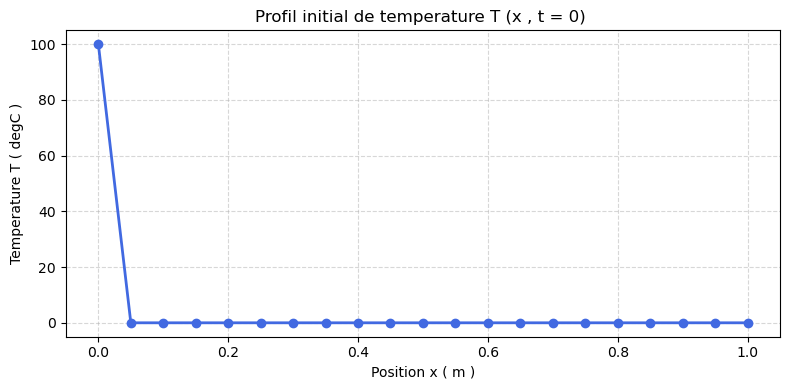

In [2]:
# - - - Creation de la grille spatiale - - -
x = np.linspace(0, L, N+1) # N + 1 points de x = 0 a x = L
# - - - Condition initiale - - -
T = np.ones (N + 1) * T_init
# - - - Application des conditions aux limites - - -
T[0] = T_gauche
T[-1] = T_droite

# - - - Visualisation du profil initial - - -
fig, ax = plt.subplots(figsize= (8, 4) )
ax.plot (x , T , "o-"  , color="royalblue", linewidth = 2 ,markersize = 6)
ax.set_xlabel (  "Position x ( m )" )
ax.set_ylabel ( "Temperature T ( degC )" )
ax.set_title ( "Profil initial de temperature T (x , t = 0) " )
ax.grid (True, linestyle = "--"  , alpha = 0.5)
plt.tight_layout()
plt.show()

In [3]:
save_frac = 10
save_step = max(1 , nt//save_frac)
T_save = [T.copy()]
t_save = [0.0]
T_new = T.copy()
for n in range (1 , nt + 1) :
# Mise a jour des noeuds interieurs ( i = 1 a N - 1)
    for i in range (1 , N ) :
        T_new[i] = T[i] + r * (T[i+1] - 2*T[i] + T[i-1])
    T = T_new.copy() # pourquoi " copy " ?
    # Sauvegarde periodique
    if n % save_step == 0:
        T_save.append(T.copy()) # pourquoi " copy " ?
        t_save.append(n * dt)
T_save = np.array ( T_save )
print ( f" Nombre de profils sauvegardes : {len(T_save)} " )


 Nombre de profils sauvegardes : 11 


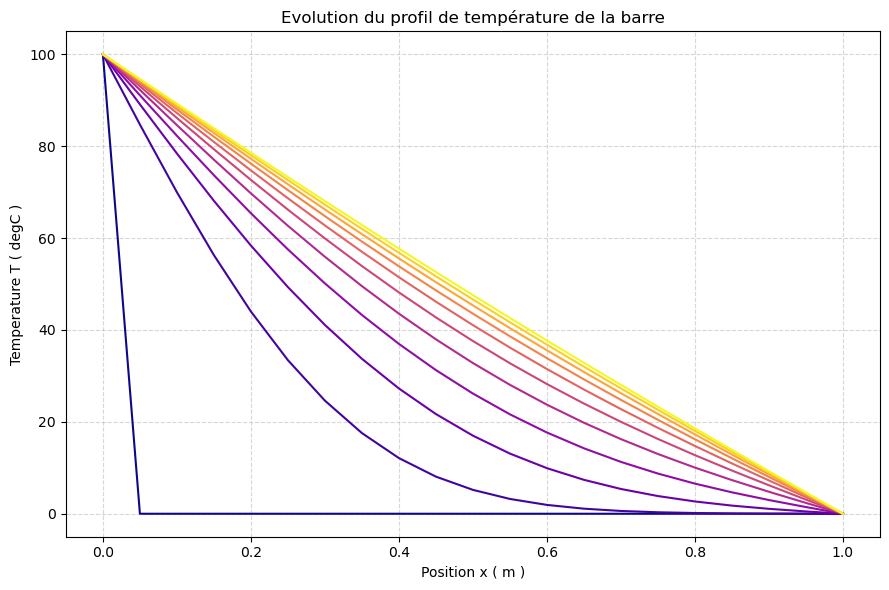

In [4]:
fig , ax = plt.subplots(figsize = (9 , 6) )
colors = cm.plasma(np.linspace(0 , 1 , len(T_save)))

for k, (T_k, t_k) in enumerate(zip(T_save, t_save)):
    ax.plot (x , T_k , color=colors[k], label=f"t = {t_k:.0f} s")

ax.set_xlabel (  "Position x ( m )" )
ax.set_ylabel ( "Temperature T ( degC )" )
ax.set_title ( "Evolution du profil de température de la barre" )
ax.grid (True, linestyle = "--"  , alpha = 0.5)
plt.tight_layout()
plt.show()

 Nombre de profils sauvegardes : 11 


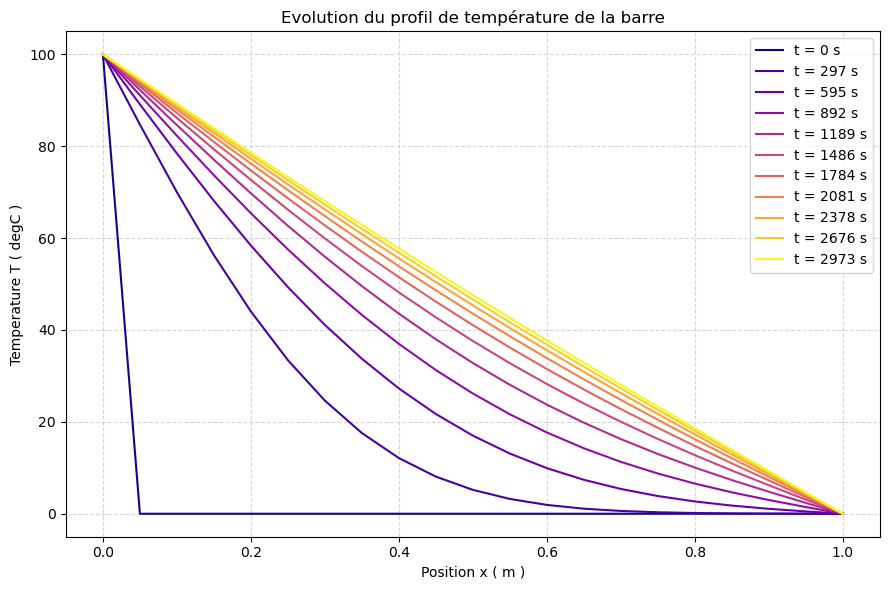

In [5]:
from sim import *

x, t, T = simulation_chaleur(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init)

Tracer_T_x(x, t, T)

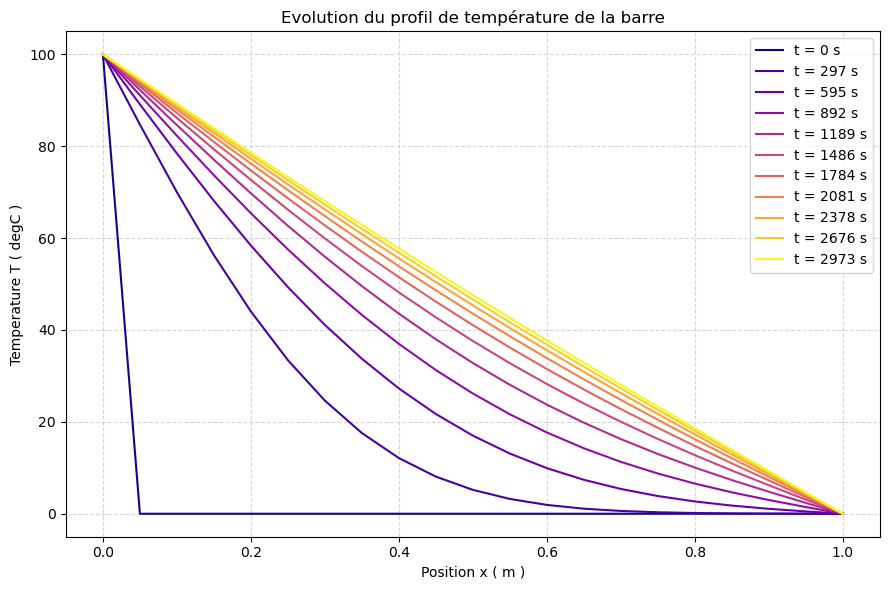

In [6]:
x, t, T = simulation_chaleur_vect(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init)

Tracer_T_x(x, t, T)